# Car Dekho Data Analysis

## 1. Data Preprocessing : Identifying Data set


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [6]:
print("(Rows, Columns) :", df.shape)

(Rows, Columns) : (301, 9)


In [7]:
print("Column Names : ")
for i in df.columns:
  print(" ", i)

Column Names : 
  Car_Name
  Year
  Selling_Price
  Present_Price
  Kms_Driven
  Fuel_Type
  Seller_Type
  Transmission
  Owner


In [8]:
print("Datatypes :")
df.dtypes

Datatypes :


,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## 2. Data Preprocessing : Checking and Handling NULL values

In [11]:
df.isnull().sum() # DATASET CONSIST NO NULL VALUES

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


## 3. Data Preprocessing : Checking and removing duplicates

In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
df[df.duplicated()] # Not exact duplicate they are different records

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


## 4. Checking For Outliers

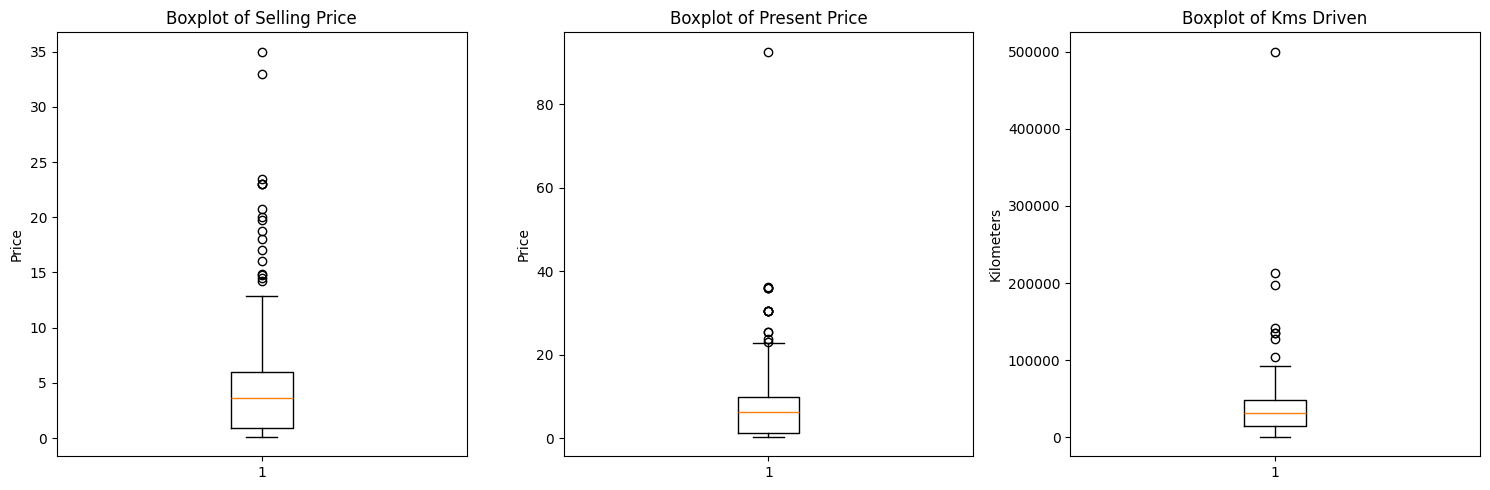

In [14]:
plt.figure(figsize=(15, 5))

# Boxplot for Selling Price
plt.subplot(1, 3, 1)
plt.boxplot(df["Selling_Price"])
plt.title("Boxplot of Selling Price")
plt.ylabel("Price")

# Boxplot for Present Price
plt.subplot(1, 3, 2)
plt.boxplot(df["Present_Price"])
plt.title("Boxplot of Present Price")
plt.ylabel("Price")

# Boxplot for Kms Driven
plt.subplot(1, 3, 3)
plt.boxplot(df["Kms_Driven"])
plt.title("Boxplot of Kms Driven")
plt.ylabel("Kilometers")

plt.tight_layout()
plt.show()

In [15]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Applying the function to remove outliers
df_cleaned = df.copy()
for col in ['Selling_Price', 'Present_Price', 'Kms_Driven']:
    df_cleaned = remove_outliers(df_cleaned, col)

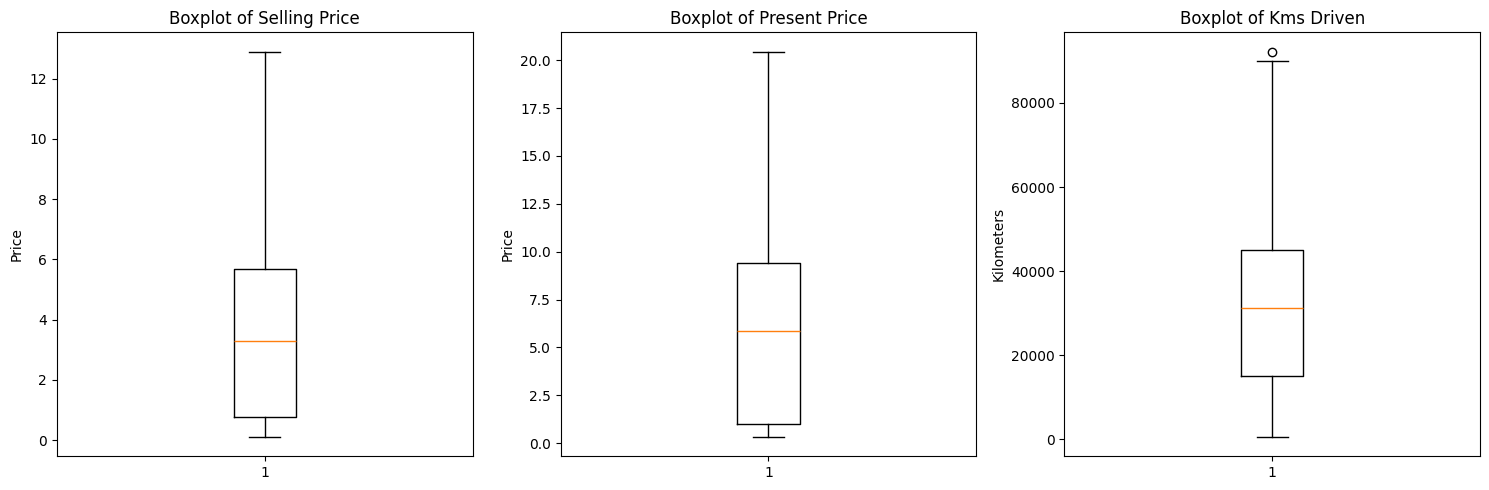

In [16]:
plt.figure(figsize=(15, 5))

# Boxplot for Selling Price
plt.subplot(1, 3, 1)
plt.boxplot(df_cleaned["Selling_Price"])
plt.title("Boxplot of Selling Price")
plt.ylabel("Price")

# Boxplot for Present Price
plt.subplot(1, 3, 2)
plt.boxplot(df_cleaned["Present_Price"])
plt.title("Boxplot of Present Price")
plt.ylabel("Price")

# Boxplot for Kms Driven
plt.subplot(1, 3, 3)
plt.boxplot(df_cleaned["Kms_Driven"])
plt.title("Boxplot of Kms Driven")
plt.ylabel("Kilometers")

plt.tight_layout()
plt.show()

# Analysis 1 : CAR AGE VS SELLING PRICE


In [17]:
df.groupby('Year')['Selling_Price'].mean()

,Selling_Price
Year,
2003,1.300000
2004,1.500000
2005,2.487500
2006,1.437500
2007,0.160000
2008,1.002857
2009,2.816667
2010,5.262667
2011,2.375263


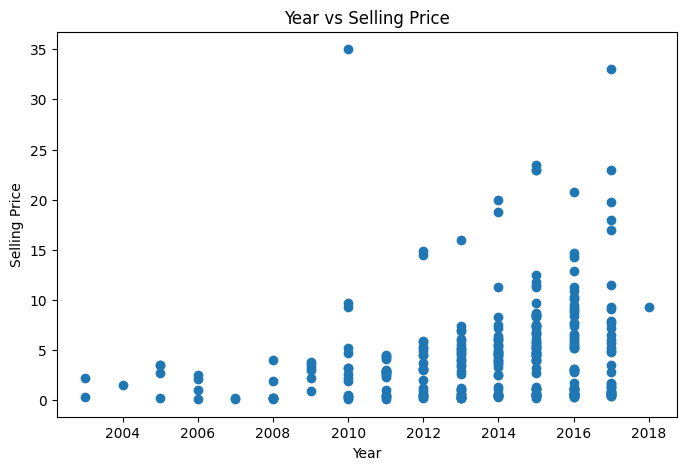

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['Year'], df['Selling_Price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Year vs Selling Price')
plt.show()

# Analysis 2 : KMS DRIVEN VS SELLING PRICE

In [19]:
df['Kms_Driven'].corr(df['Selling_Price'])

np.float64(0.029187090674291236)

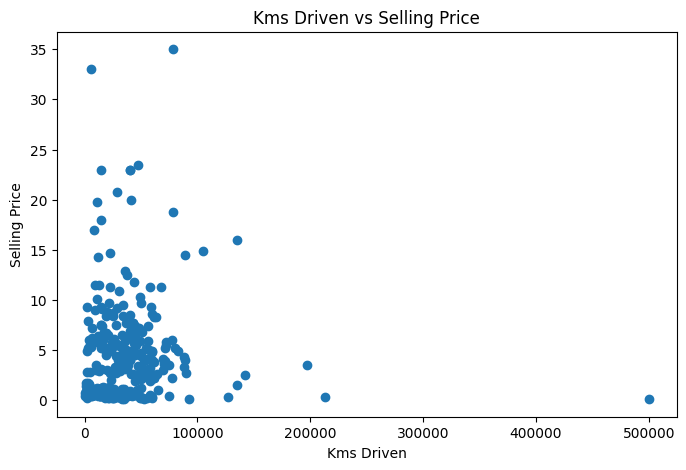

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df['Kms_Driven'], df['Selling_Price'])
plt.xlabel('Kms Driven')
plt.ylabel('Selling Price')
plt.title('Kms Driven vs Selling Price')
plt.show()

# Analysis 3 : PRESENT PRICE VS SELLING PRICE

In [21]:
df['Present_Price'].corr(df['Selling_Price'])

np.float64(0.8789825451614951)

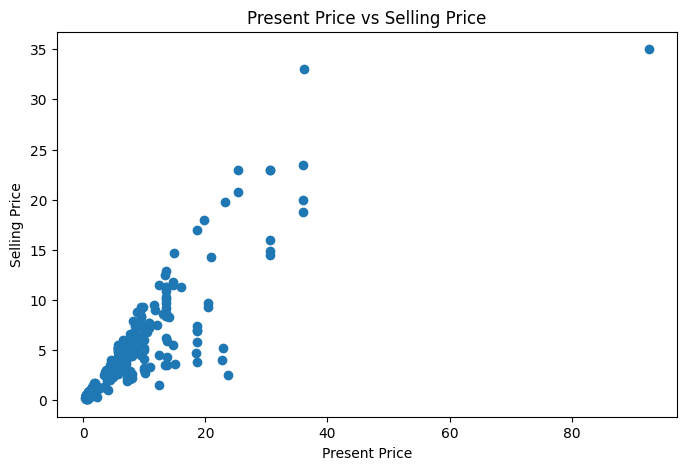

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['Present_Price'], df['Selling_Price'])
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.title('Present Price vs Selling Price')
plt.show()

# Analysis 4 : FUEL TYPE VS SELLING PRICE

In [23]:
df.groupby('Fuel_Type')['Selling_Price'].mean()

,Selling_Price
Fuel_Type,
CNG,3.100000
Diesel,10.278500
Petrol,3.264184


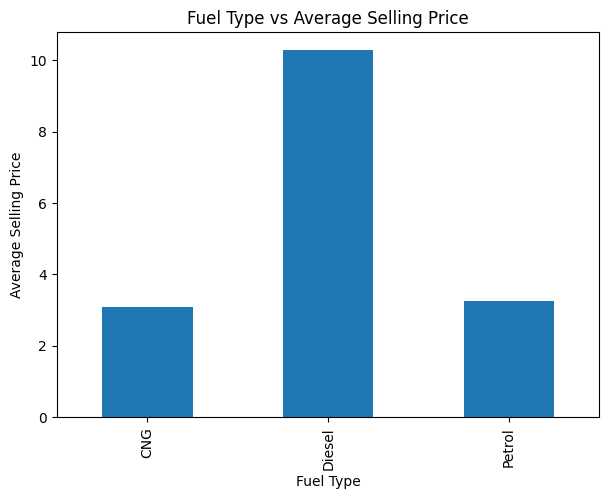

In [25]:
plt.figure(figsize=(7,5))
df.groupby('Fuel_Type')['Selling_Price'].mean().plot(kind='bar')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')
plt.title('Fuel Type vs Average Selling Price')
plt.show()

In [26]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


# Analysis 5 : TRNSMISSION VS SELLING PRICE

In [30]:
df_cleaned.groupby('Transmission')['Selling_Price'].mean()

,Selling_Price
Transmission,
Automatic,4.329091
Manual,3.705197


In [31]:
df_cleaned['Transmission'].value_counts()

,count
Transmission,
Manual,254
Automatic,22


<Figure size 700x500 with 0 Axes>

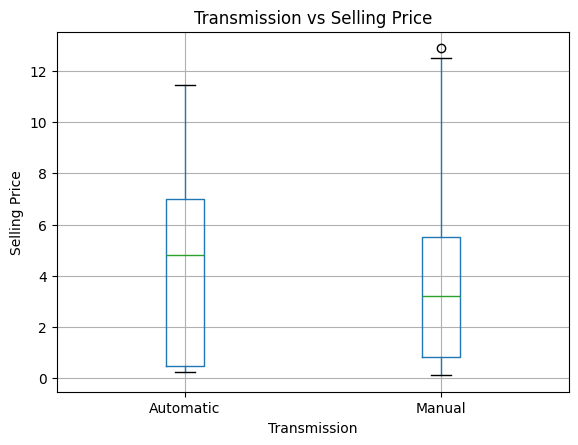

In [32]:
plt.figure(figsize=(7,5))
df_cleaned.boxplot(column='Selling_Price', by='Transmission')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.title('Transmission vs Selling Price')
plt.suptitle('')
plt.show()